# NBME EDA

檢查 Kaggle NBME - Score Clinical Patient Notes 資料集：資料表大小、標註比例、常見標註文字、缺標註情況、patient note 的標註視覺化

環境安裝 : 
```bash
pip install kaggle pandas numpy matplotlib seaborn spacy ipywidgets
```

## < 資料集下載 > 

`kaggle` 下載 competition data

step1 : 在 Kaggle 接受比賽規則

step2 : 設定好 Kaggle API credentials (Legacy Api Key)


In [ ]:
# 用 Kaggle API 下載 NBME competition 資料 解壓縮到本專案的 data/ 資料夾，並設定正確資料路徑

from pathlib import Path
import zipfile

from kaggle.api.kaggle_api_extended import KaggleApi

COMPETITION_NAME = "nbme-score-clinical-patient-notes"
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / COMPETITION_NAME
ZIP_PATH = DATA_ROOT / f"{COMPETITION_NAME}.zip"

DATA_ROOT.mkdir(parents=True, exist_ok=True)

api = KaggleApi()
api.authenticate()
api.competition_download_files(COMPETITION_NAME, path=DATA_ROOT, quiet=False)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATA_ROOT)

TRAIN_PATH = DATA_ROOT / "train.csv"
TEST_PATH = DATA_ROOT / "test.csv"
FEATURES_PATH = DATA_ROOT / "features.csv"
PATIENT_NOTES_PATH = DATA_ROOT / "patient_notes.csv"

print("專案資料路徑 DATA_ROOT:", DATA_ROOT)
print("資料檔案:")
for csv_path in [TRAIN_PATH, TEST_PATH, FEATURES_PATH, PATIENT_NOTES_PATH]:
    print(" -", csv_path.name, "存在" if csv_path.exists() else "找不到")


nbme-score-clinical-patient-notes.zip: Skipping, found more recently modified local copy (use --force to force download)
專案資料路徑 DATA_ROOT: /Users/yu/Desktop/NLP_NBME/data/nbme-score-clinical-patient-notes
資料檔案:
 - train.csv 存在
 - test.csv 存在
 - features.csv 存在
 - patient_notes.csv 存在


In [ ]:
# 載入四個 CSV，設定 pandas 顯示欄位寬度(方便檢查長文字與標註欄位)
# 四個資料表的 shape

import ast
import json
import warnings
from difflib import get_close_matches

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from spacy import displacy
import ipywidgets as widgets

pd.options.display.max_columns = 300
pd.options.display.max_colwidth = 200
pd.options.display.min_rows = 200
pd.options.display.max_rows = 500

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
features = pd.read_csv(FEATURES_PATH)
patient_notes = pd.read_csv(PATIENT_NOTES_PATH)

print("pandas version:", pd.__version__)
print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("patient_notes:", patient_notes.shape)

pandas version: 2.3.3
train: (14300, 6)
test: (5, 4)
features: (143, 3)
patient_notes: (42146, 3)


## < 欄位查看＆對應關係 >

- `case_num`：同一個標準化病例情境，同一類疾病
- `pn_num`：一份 patient note；同一個 `case_num` 會有多份不同的 note
- `feature_num` / `feature_text`：該病例要找的臨床重點
- `annotation` / `location`：note 中對應到該 feature 的答案文字與字元位置


In [ ]:
# train_merged = 合併 train、patient_notes、features [每筆訓練資料接上原始病歷文字(patient_notes)與 feature 說明(features)]
# train -> [id,case_num,pn_num,feature_num,annotation,location]
# patient_notes -> [pn_num,case_num,pn_history]
# features -> [feature_num,case_num,feature_text]

train_merged = train.merge(
    patient_notes,
    on=["case_num", "pn_num"],
    how="inner",
)
train_merged = train_merged.merge(
    features[["feature_num", "feature_text"]],
    on="feature_num",
    how="left",
)

print("train rows:", len(train))
print("train_merged rows:", len(train_merged))
train_merged.head(3)

train rows: 14300
train_merged rows: 14300


,id,case_num,pn_num,feature_num,annotation,location,pn_history,feature_text
0,00016_000,0,16,0,['dad with recent heart attcak'],['696 724'],"HPI: 17yo M presents with palpitations. Patient reports 3-4 months of intermittent episodes of ""heart beating/pounding out of my chest."" 2 days ago during a soccer game had an episode, but this ti...",Family-history-of-MI-OR-Family-history-of-myocardial-infarction
1,00016_001,0,16,1,"['mom with ""thyroid disease']",['668 693'],"HPI: 17yo M presents with palpitations. Patient reports 3-4 months of intermittent episodes of ""heart beating/pounding out of my chest."" 2 days ago during a soccer game had an episode, but this ti...",Family-history-of-thyroid-disorder
2,00016_002,0,16,2,['chest pressure'],['203 217'],"HPI: 17yo M presents with palpitations. Patient reports 3-4 months of intermittent episodes of ""heart beating/pounding out of my chest."" 2 days ago during a soccer game had an episode, but this ti...",Chest-pressure


In [ ]:
# feature_num -> 對應的臨床概念文字
# feature_text -> 模型要從 patient note 裡找出的資訊類型

features.head(10)

,feature_num,case_num,feature_text
0,0,0,Family-history-of-MI-OR-Family-history-of-myocardial-infarction
1,1,0,Family-history-of-thyroid-disorder
2,2,0,Chest-pressure
3,3,0,Intermittent-symptoms
4,4,0,Lightheaded
5,5,0,No-hair-changes-OR-no-nail-changes-OR-no-temperature-intolerance
6,6,0,Adderall-use
7,7,0,Shortness-of-breath
8,8,0,Caffeine-use
9,9,0,heart-pounding-OR-heart-racing


In [ ]:
# 基本資料分布與標註數量
# case、patient note、feature 的唯一數量，有沒有標註 location 的列數
# !- 有標註與無標註的比例 (資料不平衡程度)

print(f"Unique case num: {train_merged.case_num.nunique()}")
print(f"Unique pn num: {train_merged.pn_num.nunique()}")
print(f"Unique feature num: {train_merged.feature_num.nunique()}")
print(f"Cases with annotation: {train_merged.location[train_merged.location != '[]'].shape[0]}")
print(f"Cases without annotation: {train_merged.location[train_merged.location == '[]'].shape[0]}")

Unique case num: 10
Unique pn num: 1000
Unique feature num: 143
Cases with annotation: 9901
Cases without annotation: 4399


In [ ]:
# 檢查 feature_text 是否直接出現在 patient note 中
# 針對沒有標註 location 的列，找 feature_text 的簡化字串(find_f_txt_pn 先以全部資料找的)是否其實出現在 pn_history
# !- 無標註資料可能仍含類似文字

train_merged["find_f_txt_pn"] = train_merged.apply(
    lambda x: [
        el
        for el in x["feature_text"].lower().replace("-", " ").split(" or ")
        if el in x["pn_history"].lower()
    ],
    axis=1,
)

train_merged[train_merged.location == "[]"][["feature_text", "find_f_txt_pn"]]     .explode("find_f_txt_pn")     .groupby(["feature_text", "find_f_txt_pn"]).size()     .reset_index(name="cnt")     .sort_values("cnt", ascending=False)

,feature_text,find_f_txt_pn,cnt
13,Stress,stress,11
1,Fatigue,fatigue,4
8,Nausea,nausea,4
10,Photophobia,photophobia,2
7,Male,male,2
12,Shortness-of-breath,shortness of breath,2
11,Sharp-OR-stabbing-OR-7-to-8-out-of-10-on-pain-scale,sharp,2
19,loss-of-interest,loss of interest,2
6,Intermittent,intermittent,2
4,Hot-flashes,hot flashes,2


In [20]:
# 單筆 patient note 標註視覺化
# 標註 span 是否對齊文字、同一 note 內有哪些 feature 被標出
# !- 是否有不自然或漏標情況

def parse_locations(location_text):
    """把 Kaggle 的 location 字串轉成 list[str]，並處理同一標註中用分號分段的情況。"""
    return json.loads(location_text.replace("'", '"').replace(";", '","'))


def annotate_sample(note_num):
    note_num = int(note_num)
    warnings.filterwarnings("ignore")

    patient_df = train[train["pn_num"] == note_num].copy()
    patient_df = patient_df.merge(features[["feature_num", "feature_text"]], on="feature_num")
    patient_df["location"] = patient_df["location"].apply(parse_locations)

    ents = []
    for _, row in patient_df.iterrows():
        for span in row["location"]:
            start_loc, end_loc = span.split()
            display_label = f"[{row['feature_text']}]"
            ents.append({
                "start": int(start_loc),
                "end": int(end_loc),
                "label": display_label,
            })

    annotation = patient_df["feature_text"].apply(lambda label: f"[{label}]")
    note_text = patient_notes.loc[patient_notes["pn_num"] == note_num, "pn_history"].iloc[0]
    doc = {"text": note_text, "ents": ents}

    p1 = sns.color_palette("hls", annotation.nunique(), desat=1).as_hex()
    p2 = sns.color_palette("hls", annotation.nunique(), desat=0.5).as_hex()
    colors = {
        label: f"linear-gradient(90deg, {c1}, {c2})"
        for label, c1, c2 in zip(annotation.unique(), p1, p2)
    }

    displacy.render(doc, style="ent", options={"colors": colors}, manual=True, jupyter=True)


case_numbers = list(map(str, sorted(patient_notes["case_num"].unique())))
case_num_selector = widgets.Dropdown(
    options=case_numbers,
    value=case_numbers[0],
    description="Case No:",
)

def note_options_for_case(case_num):
    return list(map(str, sorted(train.loc[train["case_num"] == int(case_num), "pn_num"].unique())))

note_num_selector = widgets.Dropdown(
    options=note_options_for_case(case_num_selector.value),
    description="Note No:",
)

def on_case_no_change(change):
    if change["type"] == "change" and change["name"] == "value":
        note_numbers = note_options_for_case(change["new"])
        note_num_selector.options = note_numbers
        note_num_selector.value = note_numbers[0]

case_num_selector.observe(on_case_no_change)

display(case_num_selector)
display(note_num_selector)

Dropdown(description='Case No:', options=('0', '1', '2', '3', '4', '5', '6', '7', '8', '9'), value='0')

Dropdown(description='Note No:', options=('16', '41', '46', '82', '100', '161', '188', '211', '224', '225', '2…

In [ ]:
# 顯示目前選到的 note 標註
# !- 不同 feature 顏色的文字片段(train.location 指到的答案 span)是否跟feature_text相關

annotate_sample(note_num_selector.value)

## < Feature 與 Annotation 分布 >

看每個 `feature_text` 的資料量、缺標註比例、常見 annotation 文字、annotation 字詞之間是否有相近寫法

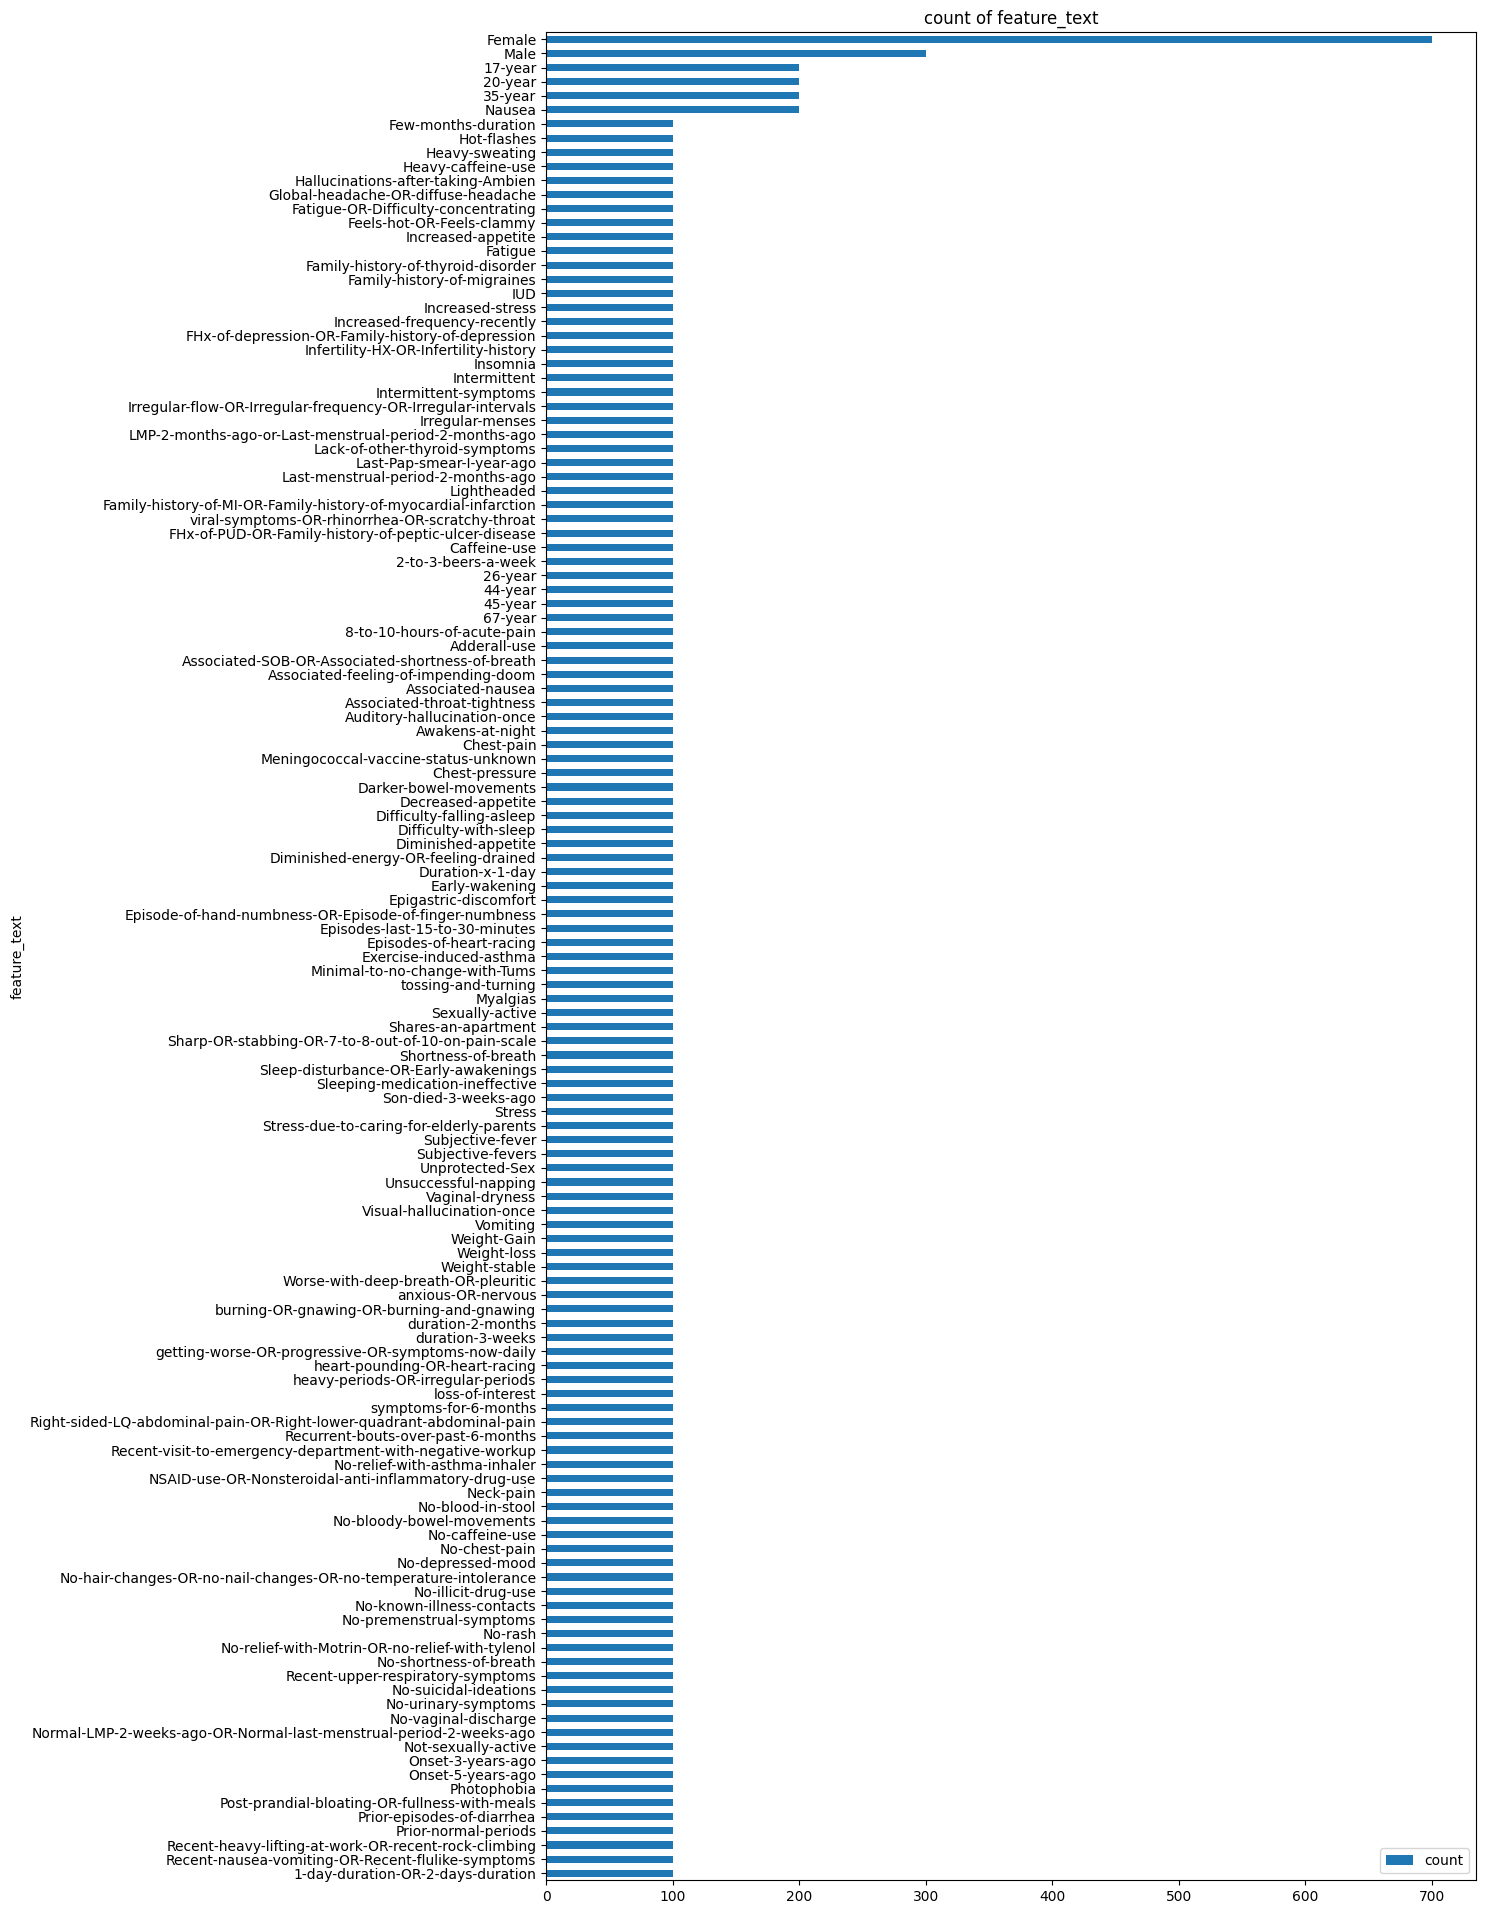

In [ ]:
# 每個 feature_text 在 train 中出現的次數
# !- 哪些 feature 資料比較少，模型可能較難學

train_merged     .groupby("feature_text").agg({"id": "count"})     .reset_index()     .rename(columns={"id": "count"})     .sort_values("count", ascending=True)     .plot(
        kind="barh",
        figsize=(12, 24),
        x="feature_text",
        y="count",
        title="count of feature_text",
    )
plt.show()

In [ ]:
# 每個 feature_text 最常見的前 5 個 annotation
# 統計每個 feature 常見的答案文字 同一個臨床概念有哪些'常見寫法'
# !- 文字變異與資料清理需求

train_merged[["feature_text", "annotation"]]     .query("annotation != '[]'")     .assign(annotation=lambda x: [ast.literal_eval(e) for e in x["annotation"]])     .explode("annotation")     .assign(annotation=lambda x: x["annotation"].str.lower())     .groupby(["feature_text", "annotation"]).size()     .reset_index(name="cnt")     .assign(rnk=lambda x: x.groupby("feature_text").cnt.transform("rank", method="max", ascending=False))     .sort_values(["feature_text", "cnt"], ascending=[True, False])     .query("rnk < 6")     .groupby("feature_text").agg({
        "annotation": lambda x: list(x),
        "cnt": lambda x: list(x),
    })     .reset_index()     .rename(columns={
        "annotation": "top 5 annotation",
        "cnt": "top 5 annotation cnt",
    })

,feature_text,top 5 annotation,top 5 annotation cnt
0,1-day-duration-OR-2-days-duration,"[yesterday, 1 day, 2 days]","[76, 14, 6]"
1,17-year,"[17 yo, 17yo, 17 year old, 17 y/o, 17-year-old]","[92, 28, 23, 17, 12]"
2,2-to-3-beers-a-week,"[few beers a week, 1-2 beers/week]","[7, 3]"
3,20-year,"[20 yo, 20yo, 20 year old, 20 y/o, 20 year]","[81, 28, 24, 22, 9]"
4,26-year,"[26, 26 yo, 26 year old, 26 y/o, 26yo]","[34, 20, 17, 9, 9]"
5,35-year,"[35 yo, 35 year old, 35yo, 35 y/o, 35-year-old]","[94, 29, 18, 17, 14]"
6,44-year,"[44, 44 yo, 44yo, 44 year old, 44 y/o]","[35, 26, 17, 6, 5]"
7,45-year,"[45 yo, 45 y/o, 45 year, 45 year old, 45yo]","[43, 15, 14, 11, 10]"
8,67-year,"[67 yo, 67 y/o, 67 year old, 67yo]","[36, 14, 14, 9]"
9,8-to-10-hours-of-acute-pain,"[started 8-10 hours ago, pain started 8-10 hours ago]","[10, 4]"


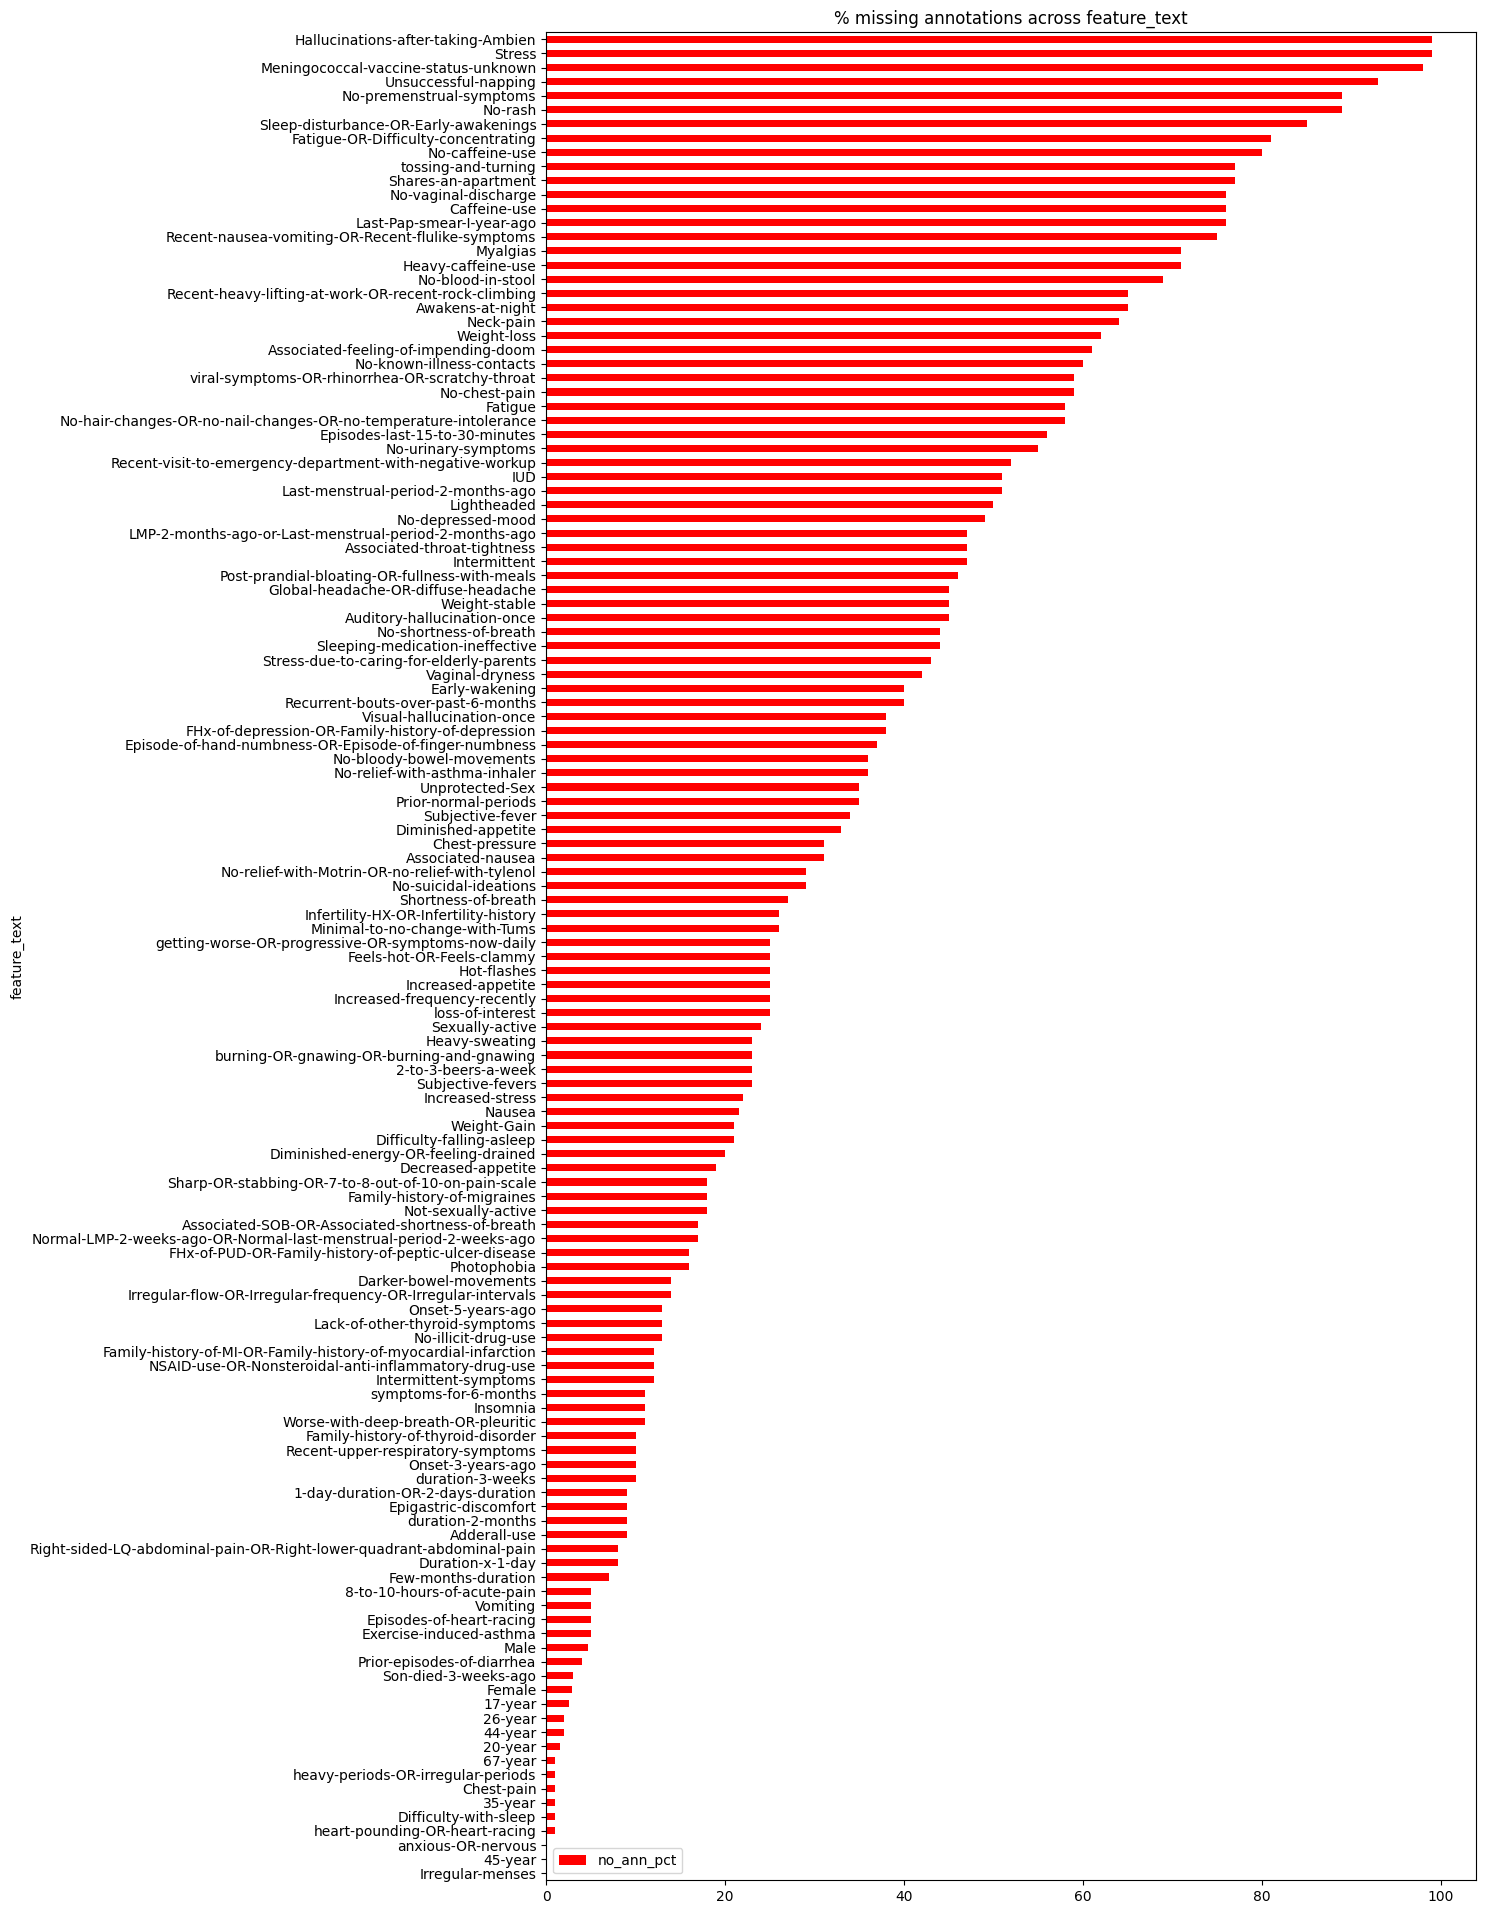

In [ ]:
# 每個 feature_text 的缺標註比例
# 計算 location == [] (有feature_text內容但未標注) 的比例
# !- 缺標註比例高的 feature -> train row 是負樣本，訓練時要注意類別不平衡

train_merged.assign(no_ann=lambda x: x["location"] == "[]")     .groupby("feature_text").agg(
        count=("no_ann", "count"),
        no_ann_pct=("no_ann", lambda z: 100 * np.mean(z)),
    )     .reset_index()     .sort_values("no_ann_pct", ascending=True)     .plot(
        kind="barh",
        figsize=(12, 24),
        x="feature_text",
        y="no_ann_pct",
        title="% missing annotations across feature_text",
        color="red",
    )
plt.show()

In [ ]:
# 每個 feature_text 最常見的 annotation 單字
# 把 annotation 拆成單字後統計頻率 -> 常見關鍵詞與停用詞
# !- 幫助後續若做規則或錯誤分析時

train_merged_split_words = train_merged[["feature_text", "annotation"]]     .query("annotation != '[]'")     .assign(annotation=lambda x: [ast.literal_eval(e) for e in x["annotation"]])     .explode("annotation")     .assign(annotation=lambda x: [str(y).lower().split() for y in x["annotation"]])     .explode("annotation")     .groupby(["feature_text", "annotation"]).size()     .reset_index(name="cnt")     .assign(rnk=lambda x: x.groupby("feature_text").cnt.transform("rank", method="max", ascending=False))     .sort_values(["feature_text", "cnt"], ascending=[True, False])

train_merged_split_words.query("rnk < 6")     .groupby("feature_text").agg({
        "annotation": lambda x: list(x),
        "cnt": lambda x: list(x),
    })     .reset_index()     .rename(columns={
        "annotation": "top 5 annotation words",
        "cnt": "top 5 annotation word cnt",
    })

,feature_text,top 5 annotation words,top 5 annotation word cnt
0,1-day-duration-OR-2-days-duration,"[yesterday, day, 1, 2, days]","[76, 26, 18, 9, 7]"
1,17-year,"[17, yo, old, 17yo, year]","[149, 94, 29, 28, 24]"
2,2-to-3-beers-a-week,"[week, beers, a, few, etoh]","[29, 26, 17, 13, 12]"
3,20-year,"[20, yo, year, old, 20yo]","[158, 82, 35, 29, 28]"
4,26-year,"[26, yo, old, year]","[85, 20, 18, 18]"
5,35-year,"[35, yo, old, year, 35yo]","[164, 96, 32, 30, 18]"
6,44-year,"[44, yo, 44yo, old, year]","[79, 27, 17, 8, 8]"
7,45-year,"[45, yo, year, y/o, old]","[89, 44, 25, 15, 11]"
8,67-year,"[67, yo, old, y/o, year]","[80, 37, 18, 14, 14]"
9,8-to-10-hours-of-acute-pain,"[8-10, hours, ago, started, pain]","[71, 67, 51, 36, 34]"


In [ ]:
# 找 annotation 單字中相近的拼法
# 用 difflib 找同一 feature 下拼法相近的 annotation words
# !- 可能的同義詞、縮寫、拼字變體 -> 可文字 normalization 或錯誤分析

def get_close_matches_(words):
    words = list(dict.fromkeys(words))
    similar_words = []
    while len(words) > 1:
        ref_word = words[0]
        words = words[1:]
        matches = get_close_matches(ref_word, words, cutoff=0.75)
        if matches:
            similar_words.append(matches + [ref_word])
            words = list(set(words) - set(matches))
    return similar_words

train_merged_split_words     .groupby("feature_text")     .apply(lambda x: list(x["annotation"]))     .reset_index()     .rename(columns={0: "annotation words"})     .assign(similar_words=lambda x: [get_close_matches_(words) for words in x["annotation words"]])     [["feature_text", "similar_words"]]     .explode("similar_words")     .assign(len_=lambda x: [len(words) if isinstance(words, list) else 0 for words in x["similar_words"]])     .sort_values("len_", ascending=False)     [["feature_text", "similar_words"]]

,feature_text,similar_words
43,Global-headache-OR-diffuse-headache,"[head, ha, heard, hea]"
93,Prior-normal-periods,"[28-29d, *28-29, q.28-29, 28-29]"
56,Irregular-flow-OR-Irregular-frequency-OR-Irregular-intervals,"[light, light., light,, lighter]"
32,Exercise-induced-asthma,"[exercised, exercis, execise, exerxcise]"
94,Recent-heavy-lifting-at-work-OR-recent-rock-climbing,"[climbings, rockclimbing, climb, climbing]"
93,Prior-normal-periods,"[28days, 28-day, 25-28days, q28days]"
32,Exercise-induced-asthma,"[excersize, excercise, exercise, excercize]"
93,Prior-normal-periods,"[previously,, previosly, previous, previously]"
93,Prior-normal-periods,"[days, 4-5days, days), 4days]"
57,Irregular-menses,"[irrgular, irreuglar, irregualr, irregular]"


## < EDA 問題與後續處理重點 >


- <span style="color:orange"><b>span 邊界可能切錯</b></span>：`location` 是字元位置，模型輸出容易多抓空格、標點或少抓字  
  → 可用 **post-processing** 修正空格、標點、片段合併/切割

- <span style="color:orange"><b>正負樣本不平衡</b></span>：`location == []` 多，模型可能偏向預測空答案  
  → 訓練時注意 sampling、loss、threshold，並分 feature 看 validation 表現

- <span style="color:orange"><b>不同 feature 資料量不平均</b></span>：少量 feature 較容易學不好     
  → 可用 **K-fold / ensemble** 降低單一模型不穩定

- <span style="color:orange"><b>同一 feature 有多種寫法</b></span>：annotation 可能有縮寫、同義詞、不同語序  
  → 可用 **MLM continued pretraining** 讓模型熟悉 NBME patient note 寫法

- <span style="color:orange"><b>醫療縮寫與拼字變體多</b></span>：keyword match 不一定可靠  
  → 訓練 span extraction model，不要只靠字面比對；若做 normalization，要保留原文位置 mapping

- <span style="color:orange"><b>train/valid 可能資料洩漏</b></span>：同一 `pn_num` 或同一 case 的資訊可能太接近  
  → 切分資料時檢查 `case_num`、`pn_num`，避免驗證分數過度樂觀
